# Notebook Demo (throwaway)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/riverma/rapid-hub-1/main?labpath=docs/user-guide/tutorials/notebook-demo.ipynb)

*Click **launch binder** above to run this notebook live in your browser — no login required.*

This is a **temporary demo notebook** used to verify that Jupyter notebooks render inside the RAPID documentation site via the `mkdocs-jupyter` plugin, and that a Binder "run" button can execute it on a free public service.

It illustrates a tiny Muskingum-style flood-wave routing example — the kind of computation at the heart of RAPID.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")

NumPy version: 2.5.1


## A simple Muskingum routing step

The Muskingum method routes an inflow hydrograph through a river reach using two
parameters: the travel-time constant `K` and the weighting factor `X`.

$$O_{t} = C_0 I_{t} + C_1 I_{t-1} + C_2 O_{t-1}$$

In [2]:
def muskingum(inflow, K=12.0, X=0.2, dt=6.0):
    """Route an inflow hydrograph through a single reach."""
    denom = 2 * K * (1 - X) + dt
    c0 = (dt - 2 * K * X) / denom
    c1 = (dt + 2 * K * X) / denom
    c2 = (2 * K * (1 - X) - dt) / denom
    outflow = np.zeros_like(inflow)
    outflow[0] = inflow[0]
    for t in range(1, len(inflow)):
        outflow[t] = c0 * inflow[t] + c1 * inflow[t - 1] + c2 * outflow[t - 1]
    return outflow

hours = np.arange(0, 96, 6.0)
# A synthetic triangular flood wave (m^3/s)
inflow = 50 + 200 * np.exp(-((hours - 30) ** 2) / (2 * 10.0 ** 2))
outflow = muskingum(inflow)

print(f"Peak inflow:  {inflow.max():6.1f} m^3/s at t={hours[inflow.argmax()]:.0f} h")
print(f"Peak outflow: {outflow.max():6.1f} m^3/s at t={hours[outflow.argmax()]:.0f} h")

Peak inflow:   250.0 m^3/s at t=30 h
Peak outflow:  206.6 m^3/s at t=42 h


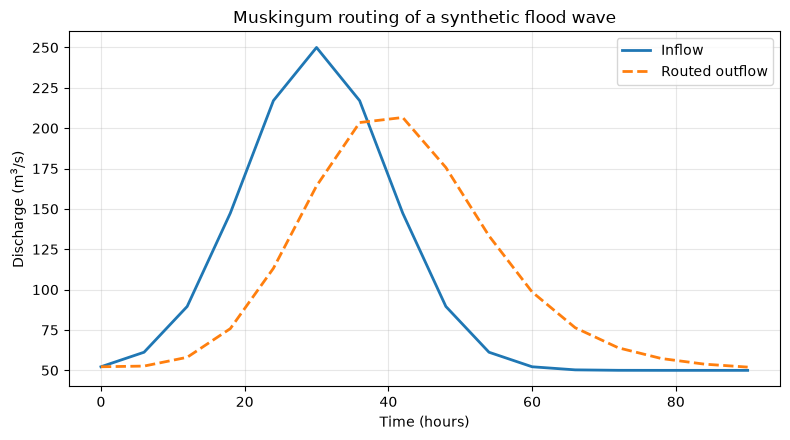

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hours, inflow, label="Inflow", lw=2)
ax.plot(hours, outflow, label="Routed outflow", lw=2, ls="--")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Discharge (m$^3$/s)")
ax.set_title("Muskingum routing of a synthetic flood wave")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()